In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

### Exploratory Data Analysis.

In [2]:
df = pd.read_csv('DataSetTwitter.csv', encoding='ISO-8859-1')

df.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


> _Let's put names in which columns to the dataframe above_

In [3]:
df.columns = ['sentiment', 'user_id', 'date', 'flag', 'user', 'text']

df.head()

,sentiment,user_id,date,flag,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [4]:
# Let us look at the size of the data:
df.shape

(1599999, 6)

> _Let's get the number of elements in our dataset_

In [5]:
df.size

9599994

> _Lets look at data type_

In [6]:
df.dtypes

sentiment     int64
user_id       int64
date         object
flag         object
user         object
text         object
dtype: object

> _Let's see if the dataset is missing any values._

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599999 entries, 0 to 1599998
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   sentiment  1599999 non-null  int64 
 1   user_id    1599999 non-null  int64 
 2   date       1599999 non-null  object
 3   flag       1599999 non-null  object
 4   user       1599999 non-null  object
 5   text       1599999 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


> _There are no missing values. I just need the columns 'sentiment' and 'text' for sentiment analysis._

In [8]:
df = df[['sentiment', 'text']]

df.head()

,sentiment,text
0,0,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
1,0,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
2,0,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."
4,0,@Kwesidei not the whole crew


> _Let’s check how many instances there are for each class_

In [9]:
df.groupby('sentiment').describe()

text                                        
            count  unique                        top freq
sentiment                                                
0          799999  790184  isPlayer Has Died! Sorry   210
4          800000  793506              good morning   118

> _As we can see, the number of unique samples is diferent of samples for each class, therefore the dataset has duplicates rows. Let's delete the duplicate rows._

In [10]:
df = df.drop_duplicates()
df.groupby('sentiment').describe()

text          \
            count  unique   
sentiment                   
0          790184  790184   
4          793506  793506   

                                                                                                                            \
                                                                                                                       top   
sentiment                                                                                                                    
0          is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!   
4                                                                             I LOVE @Health4UandPets u guys r the best!!    

                
          freq  
sentiment       
0            1  
4            1

In [11]:
#lets just make a quick modification instead of 4 to positive, lets change to 1 - positive
df['sentiment'] = df['sentiment'].map({0: 0, 4: 1})

In [12]:
df.groupby('sentiment').describe()

text          \
            count  unique   
sentiment                   
0          790184  790184   
1          793506  793506   

                                                                                                                            \
                                                                                                                       top   
sentiment                                                                                                                    
0          is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!   
1                                                                             I LOVE @Health4UandPets u guys r the best!!    

                
          freq  
sentiment       
0            1  
1            1

> _As we can see above, we have some special characters that we need to remove, like #, @, and url. Let's clean our data_

> Let's check each one

In [13]:
print(df[df['text'].str.contains('@')])

         sentiment  \
1                0   
3                0   
4                0   
6                0   
7                0   
...            ...   
1599988          1   
1599990          1   
1599992          1   
1599993          1   
1599998          1   

                                                                                                                                          text  
1                                                    @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds  
3                              @nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.   
4                                                                                                                @Kwesidei not the whole crew   
6                                          @LOLTrish hey  long time no see! Yes.. Rains a bit ,only a bit  LOL , I'm fine thanks , how's you ?  
7         

In [14]:
print(df[df['text'].str.contains('#')])

         sentiment  \
82               0   
174              0   
189              0   
192              0   
330              0   
...            ...   
1599936          1   
1599951          1   
1599984          1   
1599987          1   
1599998          1   

                                                                                                                                                text  
82                                                                                                                       @markhardy1974 Me too  #itm  
174                                                                 @machineplay I'm so sorry you're having to go through this. Again.  #therapyfail  
189         I activated my Selfcontrol block early, meaning I can't check out the new QC.  Regularizing my internal clock is might be difficult. #fb  
192                         @goodlaura What about Reese dying on #TTSC? And season finale next week.  #24 boring, Madame President 

In [15]:
print(df[df['text'].str.contains('www')])

         sentiment  \
42               0   
49               0   
133              0   
180              0   
221              0   
...            ...   
1599549          1   
1599567          1   
1599609          1   
1599713          1   
1599920          1   

                                                                                                                                                   text  
42                                                @JonathanRKnight Awww I soo wish I was there to see you finally comfortable! Im sad that I missed it   
49                    Broadband plan 'a massive broken promise' http://tinyurl.com/dcuc33 via www.diigo.com/~tautao Still waiting for broadband we are   
133           I'm missing you babe..  but as long as your alive I'm happy.. Yawwwnn.. I'm tired my love imma try to sleep hopefully you had a headstart  
180                                                                                             Check out my mug  http:

In [16]:
print(df[df['text'].str.contains('http')])

         sentiment  \
36               0   
49               0   
73               0   
94               0   
99               0   
...            ...   
1599960          1   
1599972          1   
1599980          1   
1599984          1   
1599995          1   

                                                                                                                                                text  
36                                                                                     @MissXu sorry! bed time came here (GMT+1)   http://is.gd/fNge  
49                 Broadband plan 'a massive broken promise' http://tinyurl.com/dcuc33 via www.diigo.com/~tautao Still waiting for broadband we are   
73                                                                                       Why won't you show my location?!   http://twitpic.com/2y2es  
94                                                             Strider is a sick little puppy  http://apps.facebook.com/dogbook/pro

> _Let's use Regular Expressions to remove these special characters and clean our data. We're gonna use a Python module named 're'._

In [17]:
# Let's create a function to do all the processes at once
import re

def preprocess_clean_text(text):
   text = re.sub(r'\d+', '', text).lower() #remove numbers and put the text in lower case
   text = re.sub(r'https\S+|http\S+|www\S+', '', text) #removing urls like https://, http://, www.
   text = re.sub(r'@\w+', '', text) # removing @
   text = re.sub(r"#(\w+)", r'\1', text) #removing #
   return text

In [18]:
df['clean_text'] = df['text'].apply(preprocess_clean_text)

In [19]:
df.head()

,sentiment,text,clean_text
0,0,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!,is upset that he can't update his facebook by texting it... and might cry as a result school today also. blah!
1,0,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds,i dived many times for the ball. managed to save % the rest go out of bounds
2,0,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
3,0,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there.","no, it's not behaving at all. i'm mad. why am i here? because i can't see you all over there."
4,0,@Kwesidei not the whole crew,not the whole crew


In [20]:
# lets remove white spaces
def remove_rwSpace(text):
    text = text.strip()
    return text

df['clean_text'] = df['clean_text'].apply(remove_rwSpace)

> _Let's check if the cleaning process worked._

In [21]:
df.loc[6,['clean_text', 'text']]

clean_text              hey  long time no see! yes.. rains a bit ,only a bit  lol , i'm fine thanks , how's you ?
text          @LOLTrish hey  long time no see! Yes.. Rains a bit ,only a bit  LOL , I'm fine thanks , how's you ?
Name: 6, dtype: object

In [22]:
df.loc[1599998,['clean_text', 'text']]

clean_text                                              happy charitytuesday
text          happy #charitytuesday @theNSPCC @SparksCharity @SpeakingUpH4H 
Name: 1599998, dtype: object

In [23]:
df.loc[1599549,['clean_text', 'text']]

clean_text                                         just started using  - great twool!  thx for recommending
text          @Jesse just started using www.socialtoo.com - great twool!  Thx for recommending @guykawasaki
Name: 1599549, dtype: object

In [24]:
df.loc[94,['clean_text', 'text']]

clean_text                                                           strider is a sick little puppy
text          Strider is a sick little puppy  http://apps.facebook.com/dogbook/profile/view/5248435
Name: 94, dtype: object

In [25]:
df.loc[368,['clean_text', 'text']]

clean_text                                                             but all says not in stock
text          @nchokkan https://www.mycomicshop.com/search?TID=395031 But all says not in stock 
Name: 368, dtype: object

> _Let's work with the clean dataset now._

In [26]:
df_clean = df[['clean_text', 'sentiment']]

In [27]:
df_clean.head(10)

,clean_text,sentiment
0,is upset that he can't update his facebook by texting it... and might cry as a result school today also. blah!,0
1,i dived many times for the ball. managed to save % the rest go out of bounds,0
2,my whole body feels itchy and like its on fire,0
3,"no, it's not behaving at all. i'm mad. why am i here? because i can't see you all over there.",0
4,not the whole crew,0
5,need a hug,0
6,"hey long time no see! yes.. rains a bit ,only a bit lol , i'm fine thanks , how's you ?",0
7,nope they didn't have it,0
8,que me muera ?,0
9,spring break in plain city... it's snowing,0


> _As you can see above, we still have some special characters like percent signs, exclamation marks, and question marks, which can interfere with our model; let's remove them._

In [28]:
def remove_characters(text):
    text = re.sub(r"[^\w']+", " ", text, flags=re.UNICODE)
    return text

# Apply the function to each sample
df_clean['clean_text'] = df_clean['clean_text'].apply(remove_characters)

C:\Users\serju\AppData\Local\Temp\ipykernel_32552\2984149720.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['clean_text'] = df_clean['clean_text'].apply(remove_characters)


In [29]:
df_clean.head(10)

,clean_text,sentiment
0,is upset that he can't update his facebook by texting it and might cry as a result school today also blah,0
1,i dived many times for the ball managed to save the rest go out of bounds,0
2,my whole body feels itchy and like its on fire,0
3,no it's not behaving at all i'm mad why am i here because i can't see you all over there,0
4,not the whole crew,0
5,need a hug,0
6,hey long time no see yes rains a bit only a bit lol i'm fine thanks how's you,0
7,nope they didn't have it,0
8,que me muera,0
9,spring break in plain city it's snowing,0


> _Let's select some tweets to see if the sentiment label matches the sentiment of the tweets. Positive 1, Negative 0._

In [30]:
df_clean[df_clean['sentiment'] == 1]

,clean_text,sentiment
799999,i love u guys r the best,1
800000,im meeting up with one of my besties tonight cant wait girl talk,1
800001,thanks for the twitter add sunisa i got to meet you once at a hin show here in the dc area and you were a sweetheart,1
800002,being sick can be really cheap when it hurts too much to eat real food plus your friends make you soup,1
800003,he has that effect on everyone,1
...,...,...
1599994,just woke up having no school is the best feeling ever,1
1599995,thewdb com very cool to hear old walt interviews â,1
1599996,are you ready for your mojo makeover ask me for details,1
1599997,happy th birthday to my boo of alll time tupac amaru shakur,1


In [31]:
df_clean[df_clean['sentiment'] == 0]

,clean_text,sentiment
0,is upset that he can't update his facebook by texting it and might cry as a result school today also blah,0
1,i dived many times for the ball managed to save the rest go out of bounds,0
2,my whole body feels itchy and like its on fire,0
3,no it's not behaving at all i'm mad why am i here because i can't see you all over there,0
4,not the whole crew,0
...,...,...
799994,sick spending my day laying in bed listening to,0
799995,gmail is down,0
799996,rest in peace farrah so sad,0
799997,sounds like a rival is flagging your ads not much you can do about that though,0


> _As we can see above, the expected sentiment of the tweets matches the label._

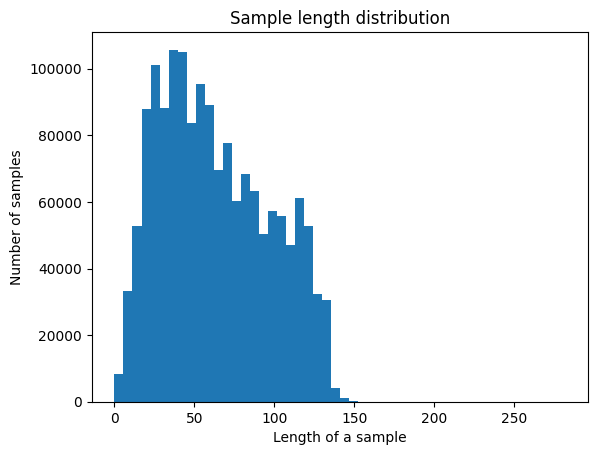

In [32]:
#lets plot the sample length distribution

import matplotlib.pyplot as plt

plt.hist([len(s) for s in df_clean['clean_text']], 50)
plt.xlabel('Length of a sample')
plt.ylabel('Number of samples')
plt.title('Sample length distribution')
plt.show()

> _Now, let's prepare and vectorize the text in the Text column. Let's split the dataset in 80% for training and 20% for testing, and use CountVectorizer and TfidfVectorizer._

In [33]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

#vectorizer = CountVectorizer(ngram_range=(1, 2), stop_words='english', min_df=30)

# After some testing, I decided to remove the stop_words='english' parameter and min_df=30.
# Because without these parameters, the accuracy went from 76% to 80%.

count_vectorizer = CountVectorizer(ngram_range=(1, 2))
#count_vectorizer = CountVectorizer(max_features=100000, ngram_range=(1, 3)) # testing max_feature not improve accuracy

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))

> _Now lets split the dataset in 80% for training and 20% for testing, and use CountVectorized_

In [34]:
x = count_vectorizer.fit_transform(df_clean['clean_text'])

y = df_clean['sentiment']

>_Let's train and test our classifier model __Naive Bayes__._

In [35]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

# Lets define some hyperparameter to optimze our model
param_grid = {
    'alpha': [0.1, 0.5, 1.0],      # Additive smoothing parameter
    'fit_prior': [True, False]     # Whether to learn class prior probabilities
}


naiveBayes_model = MultinomialNB()

grid_searchcv = GridSearchCV(estimator=naiveBayes_model, param_grid=param_grid, cv=5, n_jobs=-1)

grid_searchcv.fit(x, y)

print("Best Hyperparameters:", grid_searchcv.best_params_)
print("Best Score:", grid_searchcv.best_score_)

Best Hyperparameters: {'alpha': 1.0, 'fit_prior': True}
Best Score: 0.7921581875240735


In [36]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

naiveBayes_model = MultinomialNB(alpha=1.0, fit_prior=True)

naiveBayes_model.fit(x_train, y_train)

print(cross_val_score(naiveBayes_model, x, y, cv=5).mean())

0.7921581875240735


> _We will use a confusion matrix to validate your trained model, utilizing the 20% of data we set aside for testing._

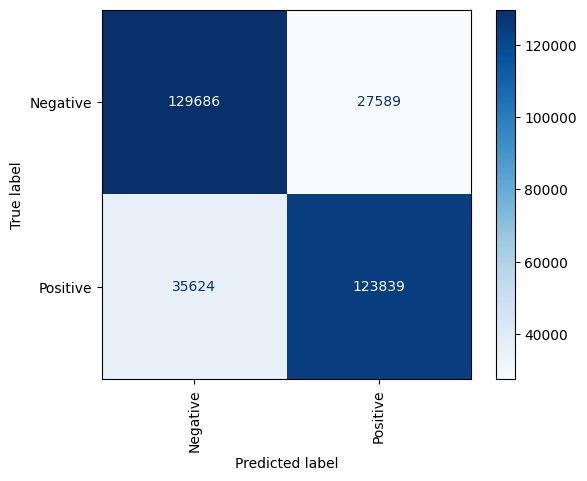

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(naiveBayes_model, x_test, y_test, display_labels=['Negative', 'Positive'], cmap='Blues', xticks_rotation='vertical');

> _The confusion matrix reveals that the model correctly identified 129,686 negative tweets while misclassifying 27,589 of them. It correctly identified 123,839 positive
tweets and got it wrong 35,624 times._

> _Let's get the model accuracy._

In [39]:
print('Naive-Bayes score: ', naiveBayes_model.score(x_test, y_test))

Naive-Bayes score:  0.8004249569044447


> _Let's analyze the ROC curve_

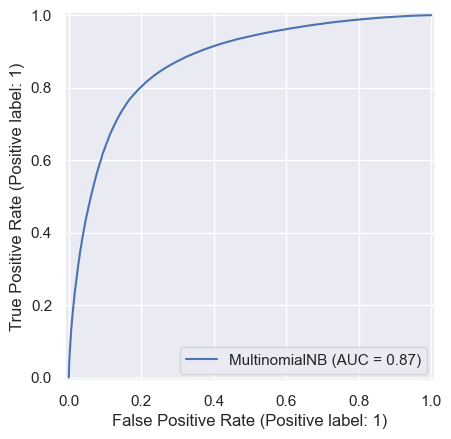

In [40]:
from sklearn.metrics import RocCurveDisplay
import seaborn as sns
sns.set()

RocCurveDisplay.from_estimator(naiveBayes_model, x_test, y_test);

> _The area under the ROC curve AUC, indicates the model is more than 85% accurate at classifying a tweet as negative or positive._

In [41]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = naiveBayes_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8004249569044447

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.82      0.80    157275
           1       0.82      0.78      0.80    159463

    accuracy                           0.80    316738
   macro avg       0.80      0.80      0.80    316738
weighted avg       0.80      0.80      0.80    316738



#### Using TF-IDF

In [42]:
x = tfidf_vectorizer.fit_transform(df_clean['clean_text'])

y = df_clean['sentiment']

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

naiveBayes_model = MultinomialNB(alpha=1.0, fit_prior=True)

naiveBayes_model.fit(x_train, y_train)

print(cross_val_score(naiveBayes_model, x, y, cv=5).mean())

0.7946245793052933


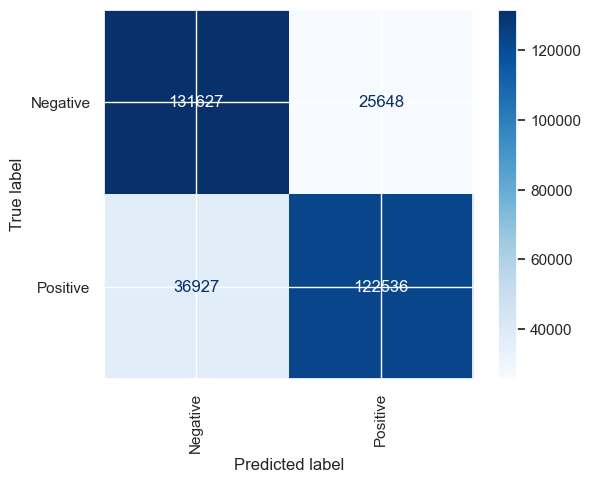

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(naiveBayes_model, x_test, y_test, display_labels=['Negative', 'Positive'], cmap='Blues', xticks_rotation='vertical');

In [45]:
print('Naive-Bayes Accuracy: ',naiveBayes_model.score(x_test, y_test))

Naive-Bayes Accuracy:  0.8024392400027783


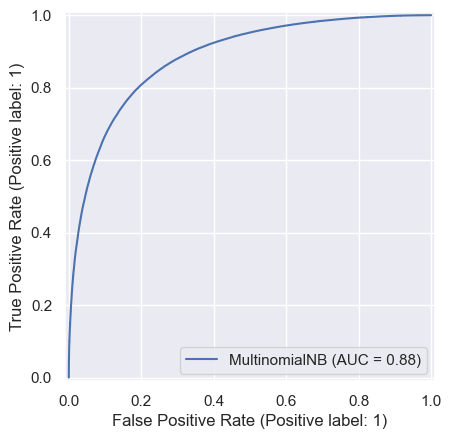

In [46]:
from sklearn.metrics import RocCurveDisplay
import seaborn as sns
sns.set()

RocCurveDisplay.from_estimator(naiveBayes_model, x_test, y_test);

In [47]:
y_pred = naiveBayes_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8024392400027783

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.84      0.81    157275
           1       0.83      0.77      0.80    159463

    accuracy                           0.80    316738
   macro avg       0.80      0.80      0.80    316738
weighted avg       0.80      0.80      0.80    316738



> _Using TF-IDF we saw a 1% improvement in our ROC curve, which rose to 88%, and minor improvements were shown in our classification report. Nothing too significant._

#### Applying Stemming

In [48]:
#!pip install nltk
import nltk
from nltk.stem import PorterStemmer

stemming = PorterStemmer()

def stem_words(text):
    words = text.split()
    stemmed_words = [stemming.stem(word) for word in words]
    return ' '.join(stemmed_words)

#def join_words(text):
    #return ''.join(text)

In [49]:
df_clean['stem_text'] = df_clean['clean_text'].apply(stem_words)

df_clean.head()

,clean_text,sentiment,stem_text
0,is upset that he can't update his facebook by texting it and might cry as a result school today also blah,0,is upset that he can't updat hi facebook by text it and might cri as a result school today also blah
1,i dived many times for the ball managed to save the rest go out of bounds,0,i dive mani time for the ball manag to save the rest go out of bound
2,my whole body feels itchy and like its on fire,0,my whole bodi feel itchi and like it on fire
3,no it's not behaving at all i'm mad why am i here because i can't see you all over there,0,no it' not behav at all i'm mad whi am i here becaus i can't see you all over there
4,not the whole crew,0,not the whole crew


In [50]:
x = tfidf_vectorizer.fit_transform(df_clean['stem_text'])
y = df_clean['sentiment']

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

naiveBayes_model = MultinomialNB(alpha=1.0, fit_prior=True)

naiveBayes_model.fit(x_train, y_train)

MultinomialNB()

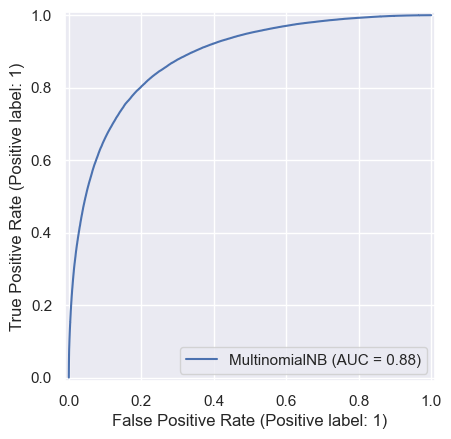

In [52]:
RocCurveDisplay.from_estimator(naiveBayes_model, x_test, y_test);

In [53]:
y_pred = naiveBayes_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7999355934557899

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.81    157275
           1       0.82      0.77      0.79    159463

    accuracy                           0.80    316738
   macro avg       0.80      0.80      0.80    316738
weighted avg       0.80      0.80      0.80    316738



>_There wasn't much difference with stemming._

#### Applying Lemmatization

In [55]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()

df_clean['lemma_text'] = df_clean['clean_text'].apply(word_tokenize)

def lemmatizer_words(tokens):
    lemmatized_words = [lemmatizer.lemmatize(word, pos='v') for word in tokens]
    return ' '.join(lemmatized_words)
    
df_clean.head()

,clean_text,sentiment,stem_text,lemma_text
0,is upset that he can't update his facebook by texting it and might cry as a result school today also blah,0,is upset that he can't updat hi facebook by text it and might cri as a result school today also blah,"[is, upset, that, he, ca, n't, update, his, facebook, by, texting, it, and, might, cry, as, a, result, school, today, also, blah]"
1,i dived many times for the ball managed to save the rest go out of bounds,0,i dive mani time for the ball manag to save the rest go out of bound,"[i, dived, many, times, for, the, ball, managed, to, save, the, rest, go, out, of, bounds]"
2,my whole body feels itchy and like its on fire,0,my whole bodi feel itchi and like it on fire,"[my, whole, body, feels, itchy, and, like, its, on, fire]"
3,no it's not behaving at all i'm mad why am i here because i can't see you all over there,0,no it' not behav at all i'm mad whi am i here becaus i can't see you all over there,"[no, it, 's, not, behaving, at, all, i, 'm, mad, why, am, i, here, because, i, ca, n't, see, you, all, over, there]"
4,not the whole crew,0,not the whole crew,"[not, the, whole, crew]"


In [56]:
df_clean['lemma_text'] = df_clean['lemma_text'].apply(lemmatizer_words)

df_clean.head()

,clean_text,sentiment,stem_text,lemma_text
0,is upset that he can't update his facebook by texting it and might cry as a result school today also blah,0,is upset that he can't updat hi facebook by text it and might cri as a result school today also blah,be upset that he ca n't update his facebook by texting it and might cry as a result school today also blah
1,i dived many times for the ball managed to save the rest go out of bounds,0,i dive mani time for the ball manag to save the rest go out of bound,i dive many time for the ball manage to save the rest go out of bound
2,my whole body feels itchy and like its on fire,0,my whole bodi feel itchi and like it on fire,my whole body feel itchy and like its on fire
3,no it's not behaving at all i'm mad why am i here because i can't see you all over there,0,no it' not behav at all i'm mad whi am i here becaus i can't see you all over there,no it 's not behave at all i 'm mad why be i here because i ca n't see you all over there
4,not the whole crew,0,not the whole crew,not the whole crew


In [57]:
x = tfidf_vectorizer.fit_transform(df_clean['lemma_text'])
y = df_clean['sentiment']

In [58]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

naiveBayes_model = MultinomialNB(alpha=1.0, fit_prior=True)

naiveBayes_model.fit(x_train, y_train)

MultinomialNB()

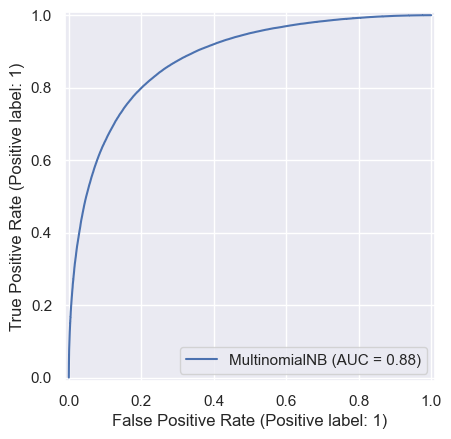

In [59]:
RocCurveDisplay.from_estimator(naiveBayes_model, x_test, y_test);

In [60]:
y_pred = naiveBayes_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7973561745038487

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.80    157275
           1       0.82      0.76      0.79    159463

    accuracy                           0.80    316738
   macro avg       0.80      0.80      0.80    316738
weighted avg       0.80      0.80      0.80    316738



>_Based on the classification report, the best results were obtained simply by applying vectorized TDF._

#### classifier model Suporte Vector Machine - SVM

In [65]:
# We had to reduce the sample size of the dataset because it was taking too long to train.

newSample_df = df_clean.sample(frac=0.02)
newSample_df = newSample_df.drop_duplicates()
newSample_df.groupby('sentiment').describe()

clean_text         \
               count unique   
sentiment                     
0              15661  15661   
1              15699  15699   

                                                                                          \
                                                                                     top   
sentiment                                                                                  
0                 i can only assume the floor actually swallowed you or just your phone    
1          watched the new moon trailer just then now just have to wait for the next one   

               stem_text                     lemma_text                         
          freq     count unique     top freq      count unique        top freq  
sentiment                                                                       
0            1     15661  15638     whi    3      15661  15638        why    3  
1            1     15699  15643  follow    4      15699  15643  thank you    3

In [66]:
from sklearn.svm import SVC

svc_x = tfidf_vectorizer.fit_transform(newSample_df['clean_text'])
svc_y = newSample_df['sentiment']

In [67]:
x_train, x_test, y_train, y_test = train_test_split(svc_x, svc_y, test_size=0.2, random_state=42)

svc_model = SVC(kernel='poly')

svc_model.fit(x_train, y_train)

SVC(kernel='poly')

In [68]:
y_pred = svc_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7252869897959183

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.65      0.71      3191
           1       0.69      0.80      0.74      3081

    accuracy                           0.73      6272
   macro avg       0.73      0.73      0.72      6272
weighted avg       0.73      0.73      0.72      6272



> _Analyzing the SVM classification report, the results were quite poor compared to Naive Bayes._

#### classifier model Logistic Regression

In [69]:
from sklearn.linear_model import LogisticRegression

lr_Sample_df = df_clean.sample(frac=0.9)

lr_Sample_df = lr_Sample_df.drop_duplicates()

lr_Sample_df.groupby('sentiment').describe()

clean_text          \
               count  unique   
sentiment                      
0             695320  695320   
1             687285  687285   

                                                                       \
                                                             top freq   
sentiment                                                               
0                                           phone is almost dead    1   
1          have a safe trip doll was thrilled to meet you at ips    1   

          stem_text                        lemma_text                         
              count  unique       top freq      count  unique       top freq  
sentiment                                                                     
0            695320  690404  miss you   11     695320  690311  miss you   11  
1            687285  681645    follow   12     687285  681776   love it    9

In [70]:
df_clean.head()

,clean_text,sentiment,stem_text,lemma_text
0,is upset that he can't update his facebook by texting it and might cry as a result school today also blah,0,is upset that he can't updat hi facebook by text it and might cri as a result school today also blah,be upset that he ca n't update his facebook by texting it and might cry as a result school today also blah
1,i dived many times for the ball managed to save the rest go out of bounds,0,i dive mani time for the ball manag to save the rest go out of bound,i dive many time for the ball manage to save the rest go out of bound
2,my whole body feels itchy and like its on fire,0,my whole bodi feel itchi and like it on fire,my whole body feel itchy and like its on fire
3,no it's not behaving at all i'm mad why am i here because i can't see you all over there,0,no it' not behav at all i'm mad whi am i here becaus i can't see you all over there,no it 's not behave at all i 'm mad why be i here because i ca n't see you all over there
4,not the whole crew,0,not the whole crew,not the whole crew


In [71]:
lr_vectorizer = TfidfVectorizer(ngram_range=(1,2))

x = lr_vectorizer.fit_transform(df_clean['stem_text'])
y = df_clean['sentiment']

In [72]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [73]:
lr_model = LogisticRegression(random_state=42, n_jobs=-1, max_iter=1000, class_weight='balanced')

lr_model.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)

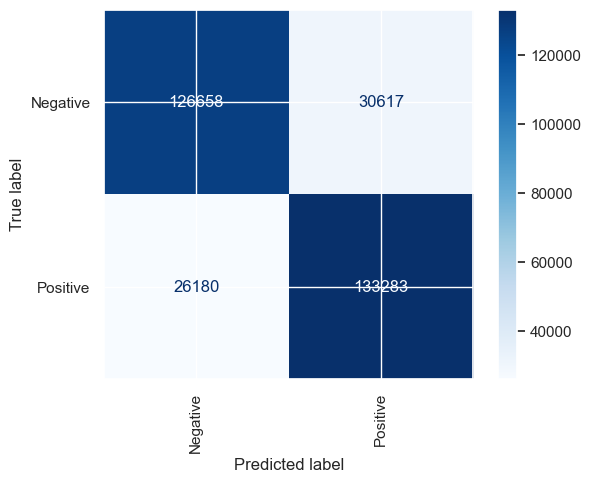

In [74]:
ConfusionMatrixDisplay.from_estimator(lr_model, x_test, y_test, display_labels=['Negative', 'Positive'], cmap='Blues', xticks_rotation='vertical')

In [75]:
print('Logistic Regression Accuracy: ',lr_model.score(x_test, y_test))

Logistic Regression Accuracy:  0.8206814464952106


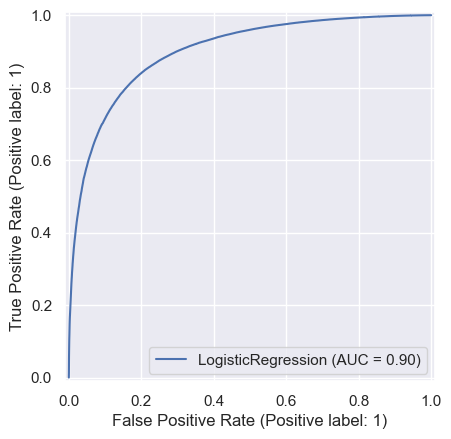

In [76]:
RocCurveDisplay.from_estimator(lr_model, x_test, y_test);

In [77]:
y_pred = lr_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8206814464952106

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82    157275
           1       0.81      0.84      0.82    159463

    accuracy                           0.82    316738
   macro avg       0.82      0.82      0.82    316738
weighted avg       0.82      0.82      0.82    316738



In [ ]:
> _So far, by far our best model, fast in training, even with large volumes of data, and a ROC AUC of 90%._